# Product Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [2]:
customers = pd.read_csv('data/customers.csv')
orders = pd.read_csv('data/orders_updated.csv')
products = pd.read_csv('data/products.csv')
sales = pd.read_csv('data/sales.csv')

In [3]:
#sales = sales.rename(columns={"quantity":"quantity_sold"})
#sales.to_csv(r"C:\data\sales_updated.csv", index=False)

In [7]:
#products = products.drop(columns=["price"])
#products.to_csv(r"C:\data\products_updated.csv", index=False)

In [12]:
# Merge Sales and Product Information
df = sales.merge(products, left_on='product_id', right_on='product_ID', how='left')
df = df.rename(columns={'quantity_x':'quantity_sold'})
df = df.rename(columns={'quantity_y':'quantity_product'})
df

,sales_id,order_id,product_id,price_per_unit,quantity_sold,total_price,product_ID,product_type,product_name,size,colour,quantity_product,description
0,0,1,218,106,2,212,218,Shirt,Chambray,L,orange,44,"A orange coloured, L sized, Chambray Shirt"
1,1,1,481,118,1,118,481,Jacket,Puffer,S,indigo,62,"A indigo coloured, S sized, Puffer Jacket"
2,2,1,2,96,3,288,2,Shirt,Oxford Cloth,M,red,54,"A red coloured, M sized, Oxford Cloth Shirt"
3,3,1,1002,106,2,212,1002,Trousers,Wool,M,blue,52,"A blue coloured, M sized, Wool Trousers"
4,4,1,691,113,3,339,691,Jacket,Parka,S,indigo,53,"A indigo coloured, S sized, Parka Jacket"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,998,321,109,2,218,321,Shirt,Mandarin Collar,S,orange,52,"A orange coloured, S sized, Mandarin Collar Shirt"
4996,4996,998,251,95,3,285,251,Shirt,Polo,S,orange,78,"A orange coloured, S sized, Polo Shirt"
4997,4997,999,872,113,1,113,872,Trousers,Chinos,M,violet,54,"A violet coloured, M sized, Chinos Trousers"
4998,4998,999,998,106,2,212,998,Trousers,Wool,L,green,42,"A green coloured, L sized, Wool Trousers"


# Product-based sales performance analysis

In [13]:
# Top 15 products by total sold quantity 
top_15 = df.groupby('product_name')['quantity_sold'].sum().nlargest(15).sort_values(ascending=False)
print(top_15)

product_name
Denim              527
Joggers            334
Pleated            308
Casual Slim Fit    306
Shearling          302
Relaxed Leg        301
Trench Coat        299
Puffer             298
Bomber             297
Chambray           290
Oxford Cloth       289
Drawstring         288
Slim-Fit           288
Windbreaker        287
Cropped            284
Name: quantity_sold, dtype: int64


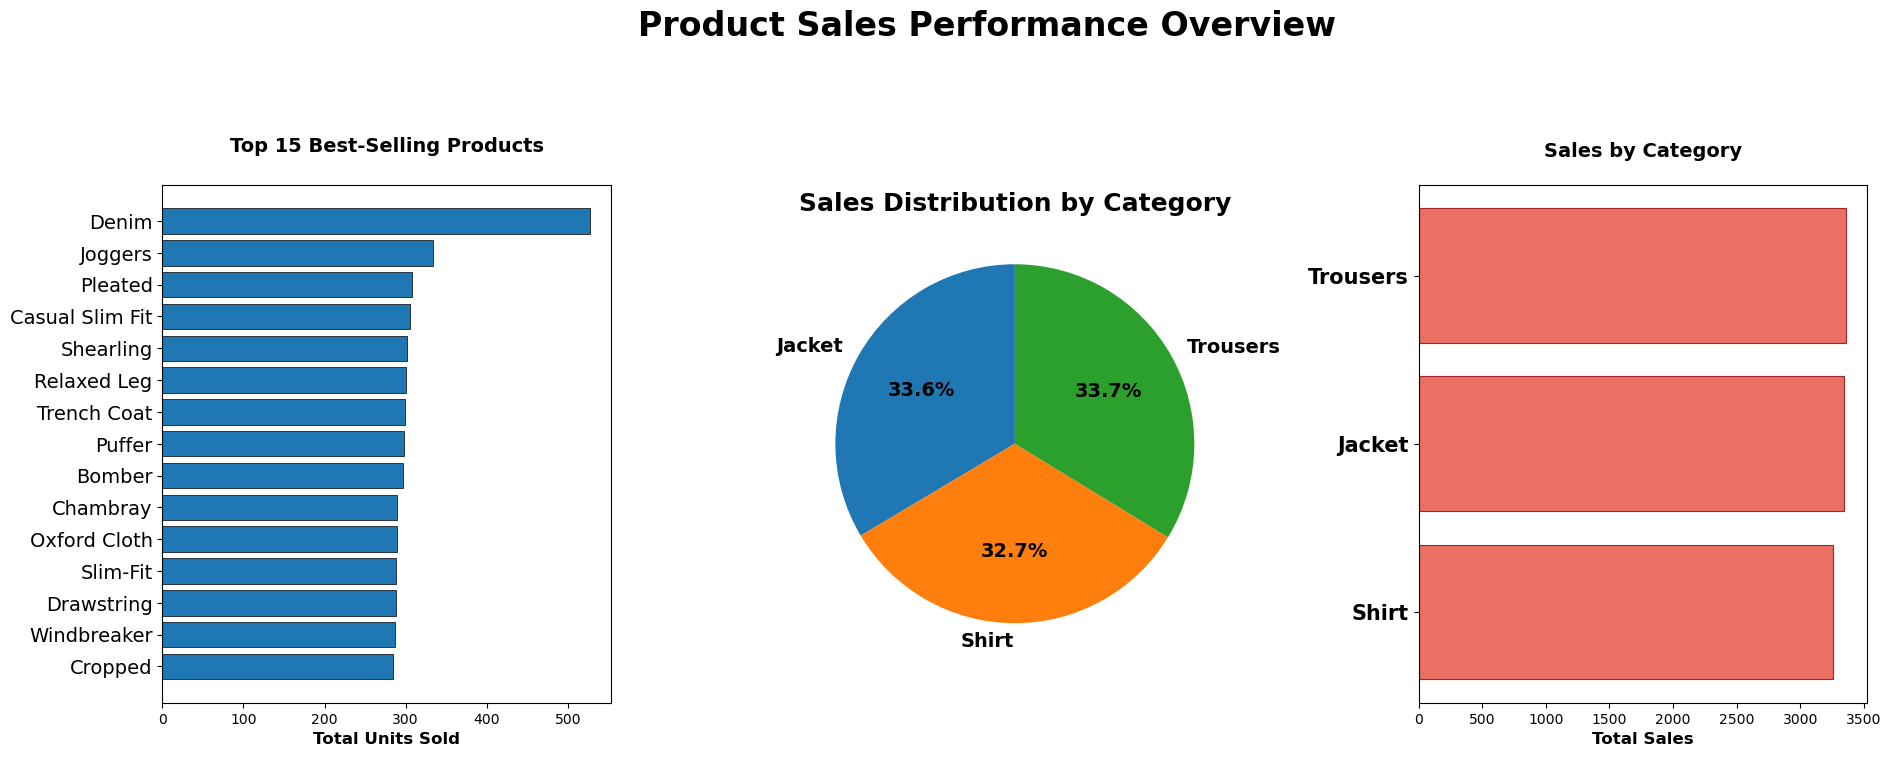

In [15]:
# Visualization: Best Sellers + Category Breakdown

fig = plt.figure(figsize=(22, 7))
gs = fig.add_gridspec(1, 3, hspace=0.4, wspace=0.4)

def pct_format(pct):
    return f'{pct:.1f}%'

# Total quantity sold per product category
type_sales = df.groupby('product_type')['quantity_sold'].sum()


# 1. Bar chart → Top 15 Best-Selling Products
ax1 = fig.add_subplot(gs[0, 0])

bars = ax1.barh(range(len(top_15)), top_15.values, edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels(top_15.index, fontsize=14)
ax1.set_xlabel('Total Units Sold', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Best-Selling Products', fontsize=14, fontweight='bold', pad=24)

# 2. Pie Chart → Category Sales Distribution
ax2 = fig.add_subplot(gs[0, 1])
patches, texts, autotexts = ax2.pie(type_sales,labels=type_sales.index,autopct=lambda pct: pct_format(pct),startangle=90,
                                    textprops={'fontsize': 14, 'fontweight':'bold'})
ax2.set_title('Sales Distribution by Category', fontsize=18, fontweight='bold')

# 3. Bar Chart → Detailed Category Sales
ax3 = fig.add_subplot(gs[0, 2])
type_sales_sorted = type_sales.sort_values()

bars = ax3.barh(range(len(type_sales_sorted)), type_sales_sorted.values,color='#e74c3c', alpha=0.8, edgecolor='darkred', linewidth=0.8)
ax3.set_yticks(range(len(type_sales_sorted)))
ax3.set_yticklabels(type_sales_sorted.index, fontsize=15, fontweight='bold')
ax3.set_xlabel('Total Sales', fontsize=12, fontweight='bold')
ax3.set_title('Sales by Category', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Product Sales Performance Overview',fontsize=24, fontweight='bold', y=1.1)
plt.subplots_adjust(top=0.85, wspace=0.3)
plt.show()


Product Sales Performance – Insights

• Denim and Joggers are the top best-selling products, indicating customer demand for casual wear.

• Sales are evenly distributed across Jackets, Shirts, and Trousers (approx. 33% each), meaning no single apparel category dominates the business.

• Inventory and marketing strategies can focus on premium casual wear, particularly Denim-based products.

# Colour & Size Preference Index

 Objective: Understand which colors and sizes are most preferred by customers, and how these preferences differ by product category.

### Color Preference Analysis

In [16]:
# Pivot Table → Category x Color matrix of total sales
category_color = df.groupby(['product_type', 'colour'])['quantity_sold'].sum().unstack(fill_value=0)
# Most demanded colors
top_colors = df.groupby('colour')['quantity_sold'].sum().nlargest(15)
top_colors.index

Index(['blue', 'violet', 'indigo', 'red', 'yellow', 'green', 'orange'], dtype='object', name='colour')

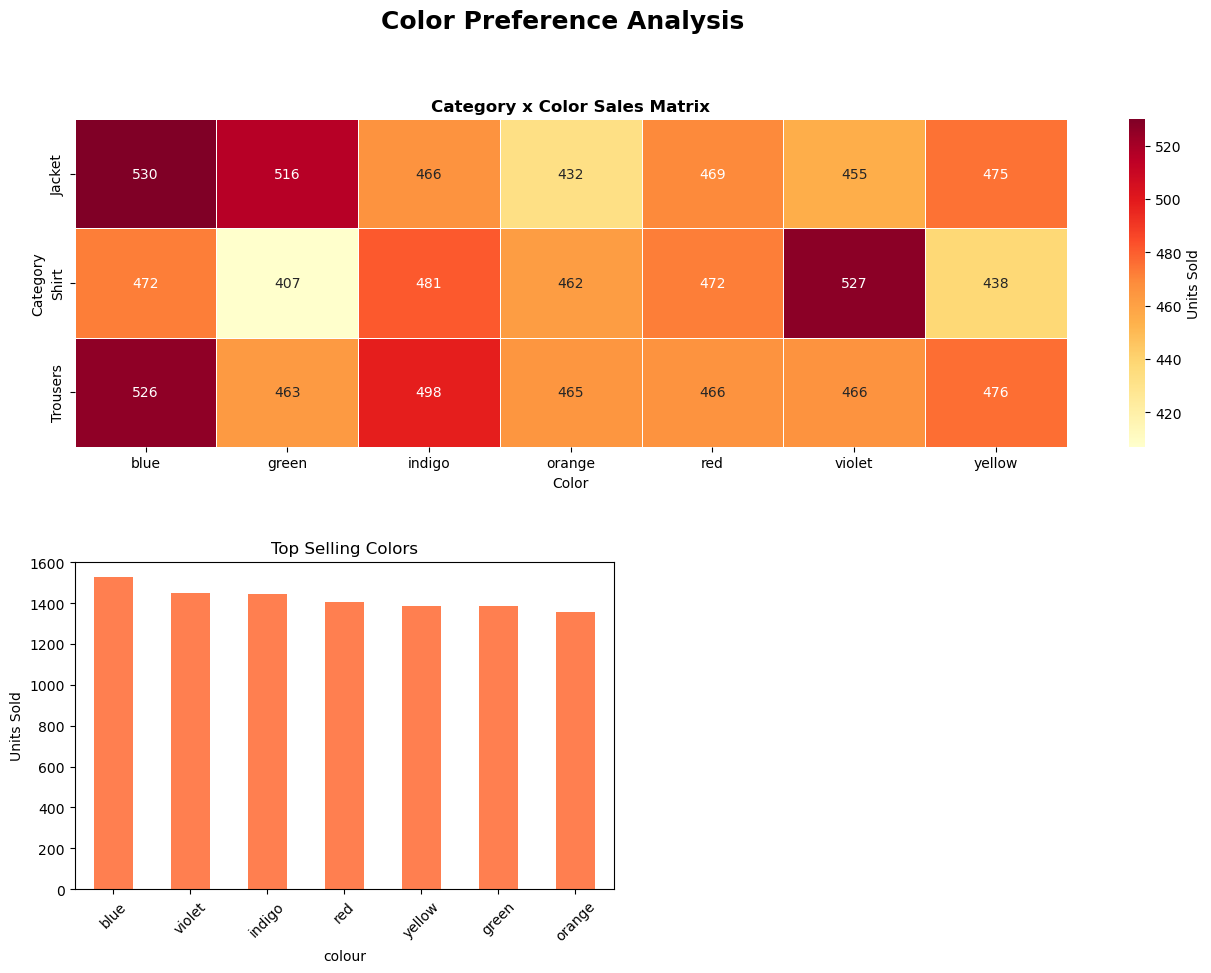

In [17]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# 1. Heatmap: Category vs Color Sales Matrix
ax1 = fig.add_subplot(gs[0, :])
category_color_filtered = category_color[category_color.columns.intersection(top_colors.index)]
sns.heatmap(category_color_filtered, annot=True, fmt='g', cmap='YlOrRd',linewidths=0.5, ax=ax1, cbar_kws={'label': 'Units Sold'})
ax1.set_title('Category x Color Sales Matrix',fontsize=12, fontweight='bold')
ax1.set_xlabel('Color')
ax1.set_ylabel('Category')

# 2. Bar Chart: Top Color Preferences Across All Products
ax2 = fig.add_subplot(gs[1, 0])
top_colors.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Top Selling Colors')
ax2.set_ylabel('Units Sold')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Color Preference Analysis', fontsize=18, fontweight='bold', y=0.99, x=0.43)
plt.show()

Color Preference – Insights

• Dark/cool colors drive most of the demand, especially in Jackets and Trousers.

• Bright colors should be planned cautiously due to lower and less consistent performance.

### Size Preference Analysis

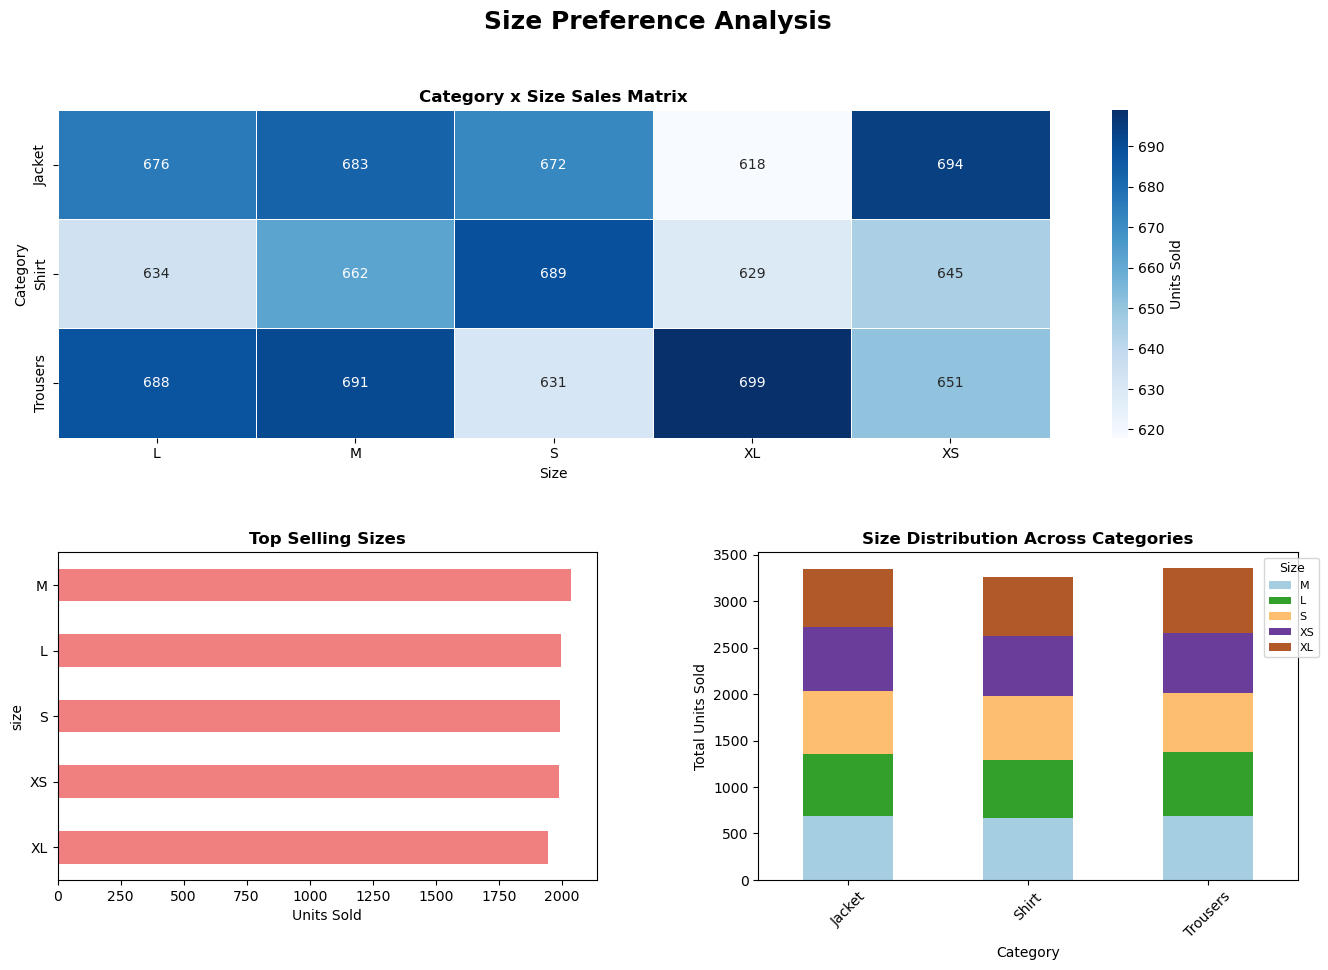

In [18]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# Pivot Table → Category x Size sales matrix
category_size = df.groupby(['product_type', 'size'])['quantity_sold'].sum().unstack(fill_value=0)

# 1. Heatmap: Category vs Size Sales Matrix
ax1 = fig.add_subplot(gs[0, :])
sns.heatmap(category_size,
            annot=True, fmt='g', cmap='Blues',
            linewidths=0.5, ax=ax1,
            cbar_kws={'label': 'Units Sold'})
ax1.set_title('Category x Size Sales Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('Size')
ax1.set_ylabel('Category')

# Top Selling Sizes 
top_sizes = df.groupby('size')['quantity_sold'].sum().nlargest(15).sort_values()

# 2. Horizontal Bar Chart: Most Purchased Sizes
ax2 = fig.add_subplot(gs[1, 0])
top_sizes.plot(kind='barh', ax=ax2, color='lightcoral')
ax2.set_title('Top Selling Sizes', fontsize=12, fontweight='bold')
ax2.set_xlabel('Units Sold')

# 3. Stacked Bar: Size distribution within each category
ax3 = fig.add_subplot(gs[1, 1])

top_sizes_list = df.groupby('size')['quantity_sold'].sum().nlargest(10).index
category_size_pivot = df.groupby(['product_type', 'size'])['quantity_sold'].sum().unstack(fill_value=0)
category_size_pivot[top_sizes_list].plot(kind='bar',
                                         stacked=True,
                                         ax=ax3,
                                         colormap='Paired')
ax3.set_title('Size Distribution Across Categories', fontsize=12, fontweight='bold')
ax3.set_xlabel('Category')
ax3.set_ylabel('Total Units Sold')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Size',
           fontsize=8,
           title_fontsize=9,
           bbox_to_anchor=(1.05, 1))

plt.suptitle('Size Preference Analysis', fontsize=18, fontweight='bold')
plt.show()

Size Preference – Insights

• Size demand is quite balanced across categories — the difference between best-selling and least-selling sizes is small (≈50–70 units), so no size is an underperformer in absolute terms.

• Medium (M) shows a slight advantage, especially in Shirts and Jackets, indicating a general consumer fit trend.

• XL performs strongly in Trousers, which suggests category-specific sizing requirements (e.g., comfort-oriented styles).

• Because variance is small, aggressive stock reduction in XS or XL would be risky — instead, inventory planning should be fine-tuned per category, not generalized.

In [19]:
# Size Demand Stability Metrics (Mean, Std, CV)

# Aggregate quantity_sold by size
size_stats = (
    df.groupby('size')['quantity_sold']
      .agg(total_units='sum',          
           mean_units='mean',          
           std_units='std')           
)

# Coefficient of Variation (CV%) = std / mean * 100
size_stats['cv_percent'] = (size_stats['std_units'] / size_stats['mean_units'] * 100)

# Round for nicer display
size_stats = size_stats.round(2)

display(size_stats.sort_values('total_units', ascending=False))


,total_units,mean_units,std_units,cv_percent
size,,,,
M,2036,1.99,0.81,40.60
L,1998,1.99,0.81,40.60
S,1992,2.00,0.80,40.14
XS,1990,1.99,0.80,40.24
XL,1946,1.99,0.82,41.16


### Size Demand Stability (Statistical View)

To better understand how stable size demand is across categories, we calculated:
- Total units sold per size  
- Average units sold per transaction  
- Standard deviation (std) of quantity  
- Coefficient of Variation (CV%) = (std / mean) × 100  

The size demand distribution is extremely **well-balanced** across categories.  
With CV% values between 40–41%, no size shows high volatility or underperformance.  
A category-level inventory strategy is recommended rather than uniform stock reduction for XS or XL sizes.  

# PRICE & STOCK ANALYSIS

Objective: Compare pricing and inventory distribution across product categories
to identify potential mismatches between demand and stock strategy.

In [24]:
# average selling price per product type
avg_price = df.groupby('product_type')['price_per_unit'].mean().sort_values(ascending=False)
avg_price

product_type
Jacket      106.628282
Shirt       102.352224
Trousers    101.508616
Name: price_per_unit, dtype: float64

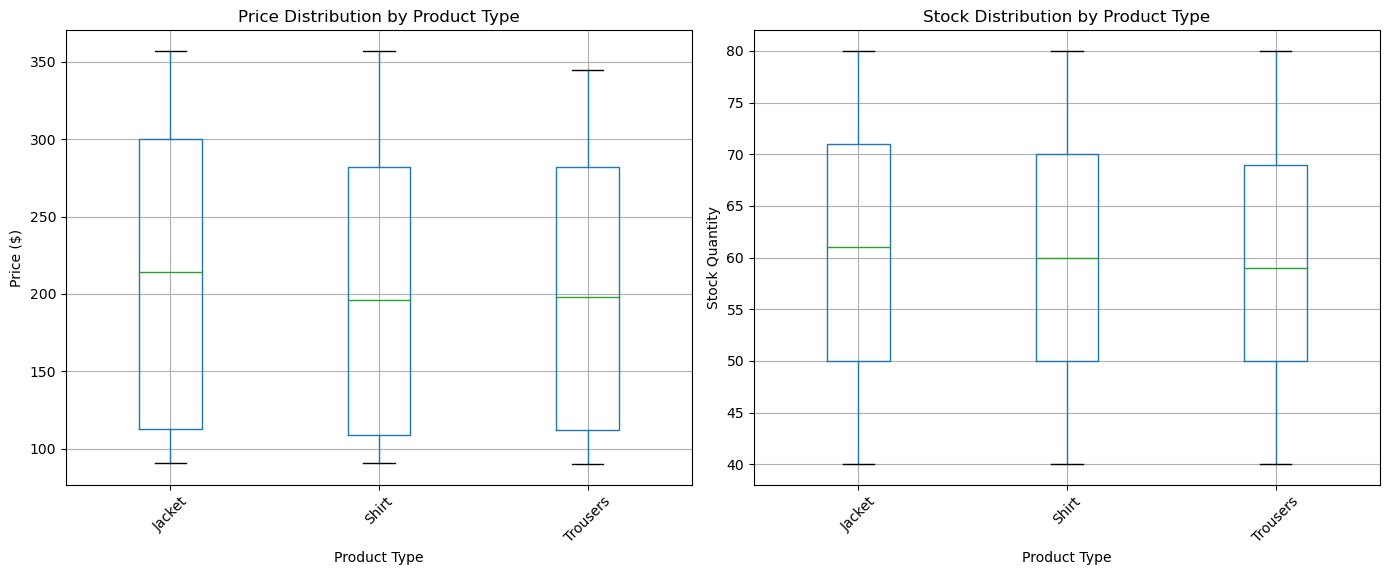

In [28]:
# Boxplots: Price & Stock Distribution by Product Type

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Price distribution by category
df.boxplot(column='total_price', by='product_type', ax=axes[0])
axes[0].set_title('Price Distribution by Product Type')
axes[0].set_xlabel('Product Type')
axes[0].set_ylabel('Price ($)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Stock distribution by category
df.boxplot(column='quantity_product', by='product_type', ax=axes[1])
axes[1].set_title('Stock Distribution by Product Type')
axes[1].set_xlabel('Product Type')
axes[1].set_ylabel('Stock Quantity')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("")  # Removes duplicate title
plt.tight_layout()
plt.show()


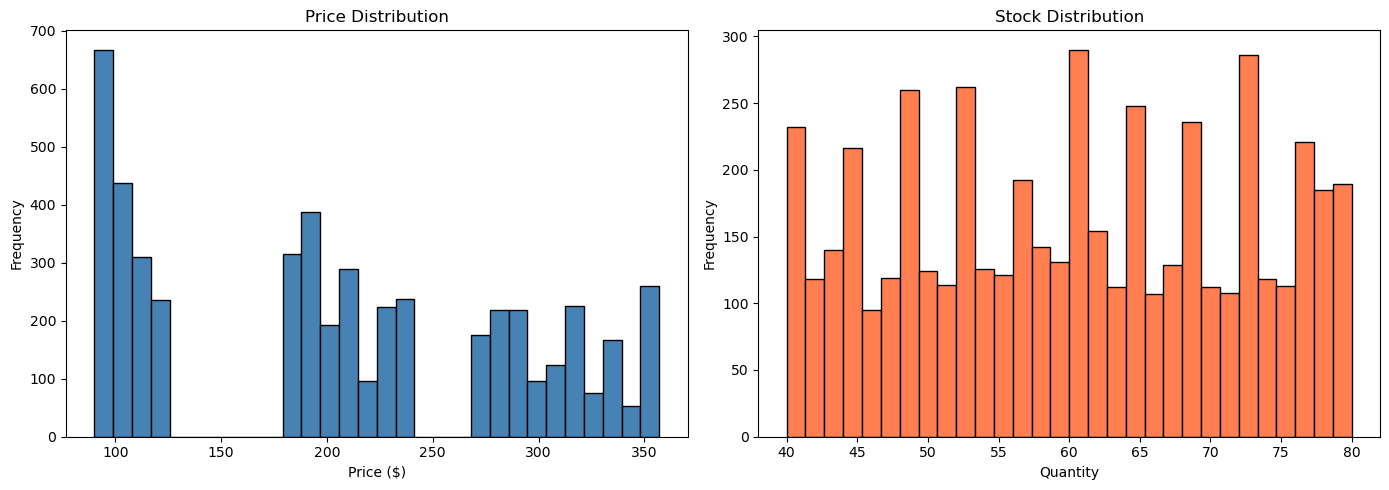

In [29]:
# General Price & Stock Profile Across All Products

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Price histogram: shows mid-premium price concentration
axes[0].hist(df['total_price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# 2. Stock histogram: shows standardized stock replenishment
axes[1].hist(df['quantity_product'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Stock Distribution')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


Insights — Price & Stock Analysis

Despite similar category averages, the overall price distribution exhibits three distinct tiers: low, mid, and high-priced product bands. This highlights a multi-level pricing strategy, indicating that pricing decisions are primarily linked to product value positioning rather than category identity.

Jackets, Shirts, and Trousers are all represented within multiple price tiers, confirming that pricing is driven by style/premium positioning more than category differences.

Stock distribution does not reflect this variation — high-priced (high-risk) items are stocked at similar levels to low-priced items.
This signals a uniform inventory policy that does not account for capital cost and demand uncertainty in premium SKUs.

To improve revenue efficiency and turnover, inventory planning should shift from category-level to SKU/price-tier-level optimization.

# Active Product Performance Analysis

 Objective: Analyze revenue contribution and unit profitability to detect high-impact products and support performance-driven segmentation.

In [30]:
# Total revenue by product type
category_revenue = df.groupby('product_type')['total_price'].sum().sort_values(ascending=False)
category_revenue


product_type
Jacket      357026
Trousers    341174
Shirt       333600
Name: total_price, dtype: int64

In [31]:
category_revenue_df = category_revenue.to_frame().reset_index()
# Calculate the share (%) of total revenue for each category to understand which categories contribute more to overall business performance.
category_revenue_df['revenue_share_%'] = 100 * category_revenue_df['total_price'] / category_revenue_df['total_price'].sum()
category_revenue_df

,product_type,total_price,revenue_share_%
0,Jacket,357026,34.602248
1,Trousers,341174,33.065904
2,Shirt,333600,32.331847


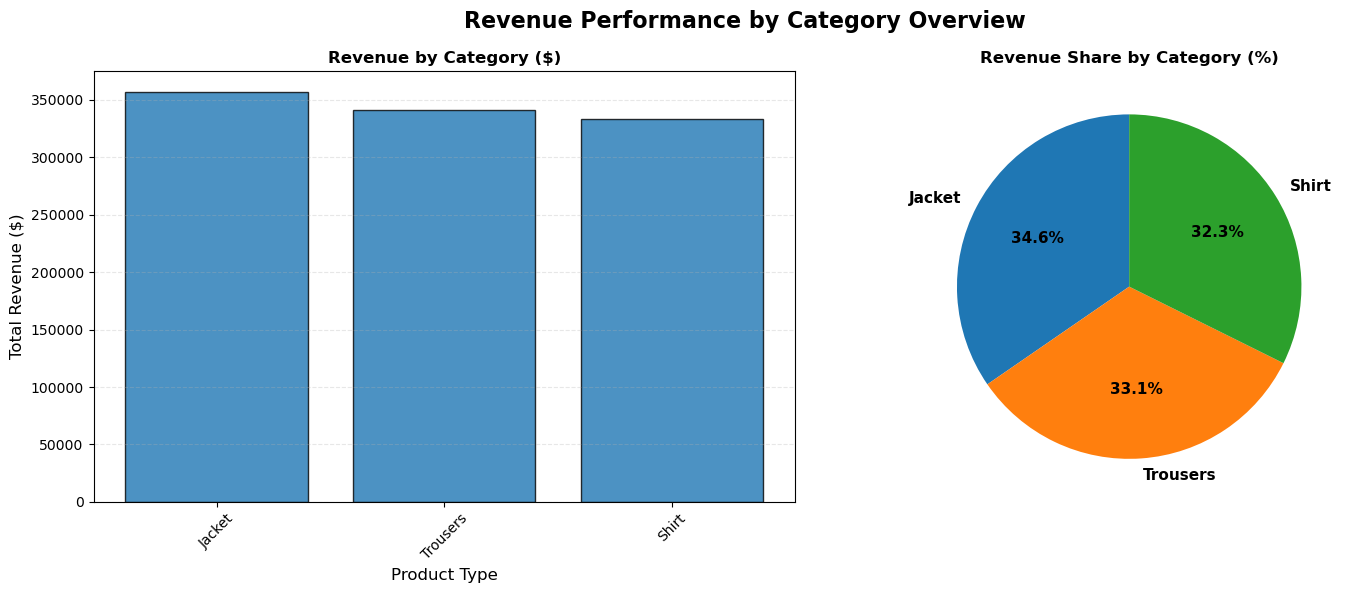

In [52]:
# Visualization: Revenue Analysis by Category

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1.Total Revenue Bar Chart
axes[0].bar(category_revenue.index, category_revenue.values, edgecolor='black', alpha=0.8)
axes[0].set_title("Revenue by Category ($)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Product Type", fontsize=12)
axes[0].set_ylabel("Total Revenue ($)", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# 2.Revenue Share (%) Pie Chart
axes[1].pie(category_revenue_df['revenue_share_%'], labels=category_revenue_df['product_type'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title("Revenue Share by Category (%)", fontsize=12, fontweight='bold')

plt.suptitle("Revenue Performance by Category Overview", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Revenue Contribution by Category Insights

Revenue distribution is balanced across categories, No over-dependent revenue risk on a single category

Since all three categories contribute almost equally, category-level expansion decisions should be evaluated based on margins and SKU-level success, not just revenue totals.

In [47]:
# Unit Profitability (Revenue per Unit Sold)
product_unit_profitability = (
    df.groupby('product_name')
      .apply(lambda x: x['total_price'].sum() / x['quantity_sold'].sum())
      .reset_index(name='unit_profitability')
      .sort_values(by='unit_profitability', ascending=False)
)
product_unit_profitability.head(15)

,product_name,unit_profitability
32,Trench Coat,119.0
4,Casual Slim Fit,119.0
26,Puffer,118.0
14,Flannel,118.0
29,Shearling,117.0
9,Cropped,115.0
22,Parka,113.0
6,Chinos,113.0
31,Tracksuit Bottoms,112.0
2,Cardigan,112.0


In [78]:
# Profitability by Category
category_profitability = (
    df.groupby('product_type')
      .apply(lambda x: x['total_price'].sum() / x['quantity_sold'].sum())
      .reset_index(name='unit_profitability')
      .sort_values(by='unit_profitability', ascending=False)
)
category_profitability

,product_type,unit_profitability
0,Jacket,106.798086
1,Shirt,102.362688
2,Trousers,101.539881


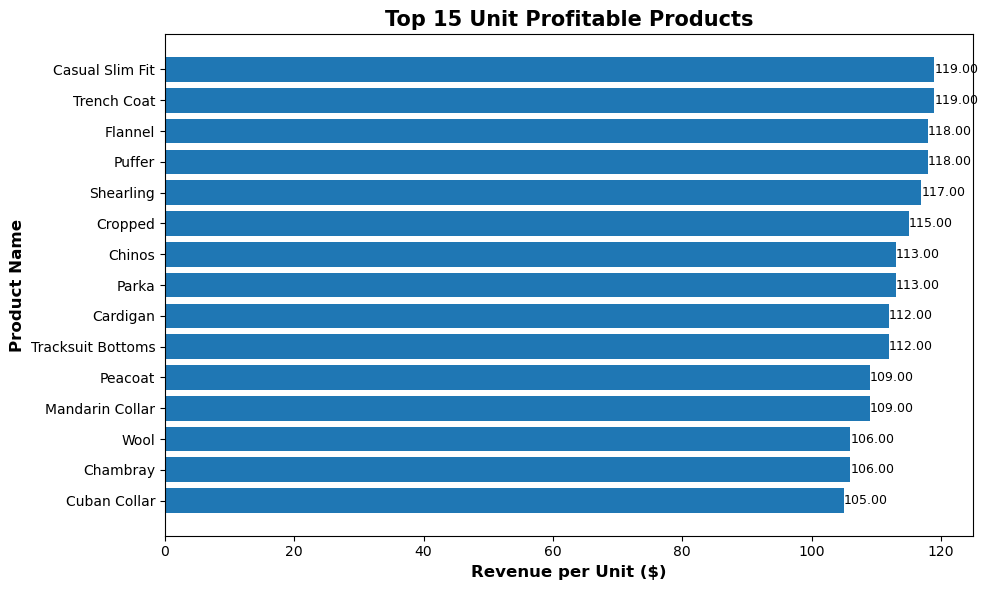

In [51]:
# Visualize Top 15 Unit Profitable Products

top15_profitability = (
    product_unit_profitability
    .head(15)
    .sort_values(by='unit_profitability'))

plt.figure(figsize=(10,6))
plt.barh(
    top15_profitability['product_name'],
    top15_profitability['unit_profitability'],)

plt.xlabel("Revenue per Unit ($)", fontsize=12, fontweight='bold')
plt.ylabel("Product Name", fontsize=12, fontweight='bold')
plt.title("Top 15 Unit Profitable Products", fontsize=15, fontweight='bold')

# Add labels to each bar
for i, v in enumerate(top15_profitability['unit_profitability']):
    plt.text(v, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


Unit Profitability Insights (Revenue per Unit)

The most profitable products are primarily outerwear, such as:
Casual Slim Fit, Trench Coat, Puffer, Shearling, Flannel— each achieving $117–$119 revenue per unit

### Product Performance Index (PPI)

Formula: PPI = Total Revenue * Total Quantity Sold

The Product Performance Index (PPI) highlights products that deliver strong business impact by combining **sales volume** and **revenue contribution**.  
Higher → high-performing in both revenue & volume

In [54]:
#Product Performance Index (PPI)

ppi = (df.groupby('product_name')
         .apply(lambda x: x['total_price'].sum() * x['quantity_sold'].sum())
         .reset_index(name='PPI')
         .sort_values(by='PPI', ascending=False))

# Scaled PPI for easier plotting
ppi['PPI_scaled'] = ppi['PPI'] / 1_000_000

print(ppi.head(15))

       product_name       PPI  PPI_scaled
11            Denim  27614273   27.614273
4   Casual Slim Fit  11142684   11.142684
29        Shearling  10670868   10.670868
32      Trench Coat  10638719   10.638719
26           Puffer  10478872   10.478872
17          Joggers  10374708   10.374708
24          Pleated   9960720    9.960720
14          Flannel   9317398    9.317398
9           Cropped   9275440    9.275440
5          Chambray   8914600    8.914600
0            Bomber   8820900    8.820900
33      Windbreaker   8401638    8.401638
22            Parka   8176793    8.176793
28      Relaxed Leg   8154090    8.154090
30         Slim-Fit   8045568    8.045568


The top-ranked products — especially Denim, Casual Slim Fit, Trench Coat, Puffer, Shearling, Joggers — prove to be standout performers not only because they are highly profitable, but also because they sell consistently at scale.

In [60]:
# 2. PPI by Category
ppi_by_category = (df.groupby('product_type')
                     .apply(lambda x: (x['total_price'].sum() * x['quantity_sold'].sum()))
                     .reset_index(name='PPI')
                     .sort_values(by='PPI', ascending=False))
# Scaled PPI for easier plotting
ppi_by_category['PPI_scaled'] = ppi_by_category['PPI'] / 1_000_000
ppi_by_category

,product_type,PPI,PPI_scaled
0,Jacket,1193537918,1193.537918
2,Trousers,1146344640,1146.344640
1,Shirt,1087202400,1087.202400


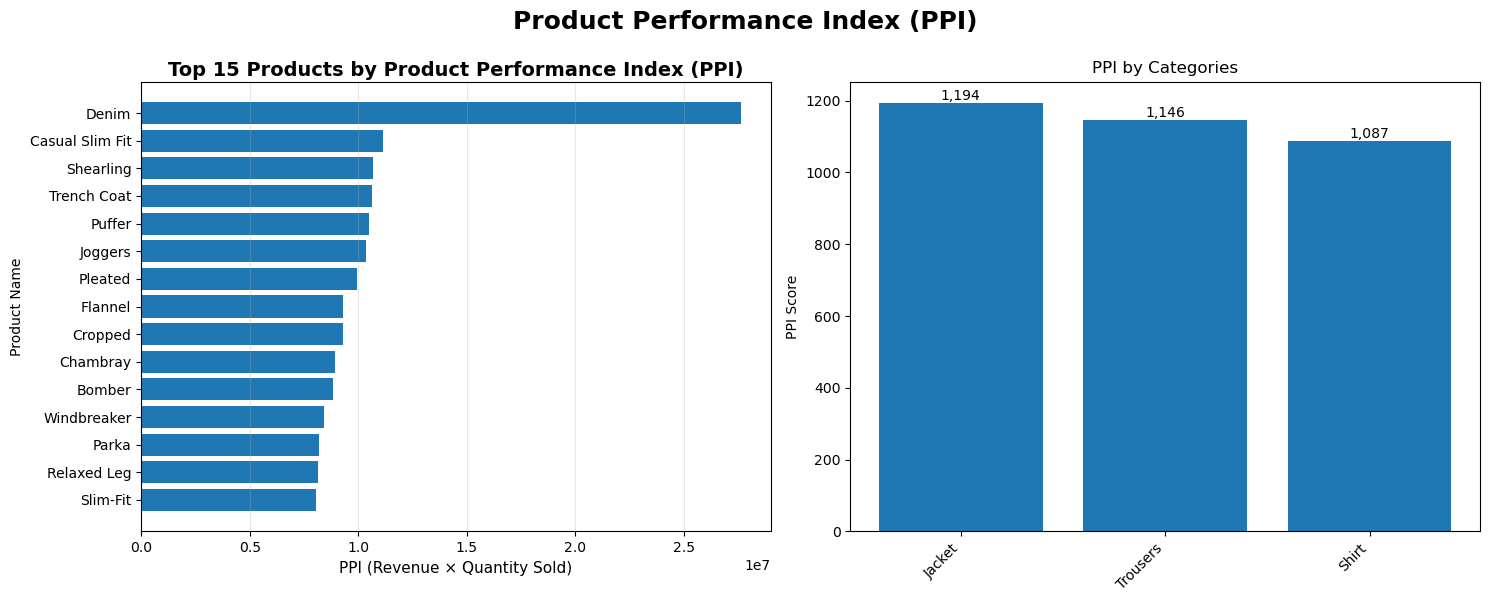

In [61]:
# Visualize Product Performance Index 

ppi_top15 = ppi.head(15).sort_values(by='PPI')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))

# 1. Top 15 products by PPI 
ax1.barh(ppi_top15['product_name'], ppi_top15['PPI'])
ax1.set_xlabel("PPI (Revenue × Quantity Sold)", fontsize=11)
ax1.set_ylabel("Product Name", fontsize=10)
ax1.set_title("Top 15 Products by Product Performance Index (PPI)", fontsize=14, fontweight='bold', pad=4)
ax1.grid(axis='x', alpha=0.3)

# 2. PPI by Category
ax2.bar(ppi_by_category['product_type'], ppi_by_category['PPI_scaled'])
ax2.set_xticks(range(len(ppi_by_category)))
ax2.set_xticklabels(ppi_by_category['product_type'], rotation=45, ha='right')
ax2.set_title('PPI by Categories')
ax2.set_ylabel('PPI Score')

# Add value labels on category bars
for i, v in enumerate(ppi_by_category['PPI_scaled']):
    ax2.text(i, v, f'{v:,.0f}', ha='center', va='bottom')

plt.suptitle('Product Performance Index (PPI)',fontsize=18, fontweight='bold', y=0.995)    
plt.tight_layout()
plt.show()


Key Findings:
- Outerwear dominates performance: 12 of the top 15 SKUs come from Jackets & winter-heavy categories → strong seasonal demand + higher willingness to pay.
- Denim is the leading SKU by a large margin (PPI is 2.5x higher than the next SKU), making it a significant revenue source and a priority for inventory coverage and marketing visibility.
- Categories show a balanced performance hierarchy



In [63]:
# Merge PPI with Unit Profitability for Segmentation
metric_df = ppi.merge(product_profitability, on='product_name', how='left')
metric_df.head()

,product_name,PPI,PPI_scaled,unit_profitability
0,Denim,27614273,27.614273,99.428843
1,Casual Slim Fit,11142684,11.142684,119.000000
2,Shearling,10670868,10.670868,117.000000
3,Trench Coat,10638719,10.638719,119.000000
4,Puffer,10478872,10.478872,118.000000


In [64]:
# export product_performance_by_ProductName file
#m = metric_df.copy()
#m.to_csv(data\product_performance_byProductName.csv",index=False, encoding='utf-8-sig')

###  Product segments (quadrant segmentation)

Products are segmented using a quadrant-based approach that combines Unit Profitability and Product Performance Index (PPI: total revenue × units sold). Median values serve as thresholds to determine high vs. low performance for both metrics, preventing outlier-driven bias. This yields four strategic groups: High Performers (high profit + high PPI), Volume Products (low profit + high PPI), Premium/Niche (high profit + low PPI), and Underperformers (low profit + low PPI). This classification reveals which items drive revenue, which rely on volume, which succeed with premium pricing, and which require optimization or removal. (Since there are no cost values ​​in the data set, they are not included in the calculation.)

In [66]:
# Median thresholds for quadrant segmentation  
profit_median = metric_df['unit_profitability'].median()
ppi_median = metric_df['PPI_scaled'].median()

print('Profit_median :',profit_median,'PPI_median :',ppi_median)

Profit_median : 102.0 PPI_median : 7.712404


In [67]:
# Define product segmentation logic (quadrant segmentation)

def segment_func(row):
    if row['unit_profitability'] >= profit_median and row['PPI_scaled'] >= ppi_median:
        return 'High Performers'
    elif row['unit_profitability'] < profit_median and row['PPI_scaled'] >= ppi_median:
        return 'Volume Products'
    elif row['unit_profitability'] >= profit_median and row['PPI_scaled'] < ppi_median:
        return 'Premium / Niche Segment'
    else:
        return 'Underperformers'

desc_mapping = {
    'High Performers': 'High Profit + High PPI. These products are strategic revenue drivers.',
    'Volume Products': 'High PPI + Low Profit. Low price, high selling volume traffic drivers.',
    'Premium / Niche Segment': 'High Profit + Low PPI. Premium positioned products with selective demand.',
    'Underperformers': 'Low Profit + Low PPI. Low demand low profit; discontinue candidate products.'
}

metric_df['segment'] = metric_df.apply(segment_func, axis=1)
metric_df['segment_description'] = metric_df['segment'].map(desc_mapping)

Description  of product segmentations:

High Performers: 'High Profit + High PPI. These products are strategic revenue drivers.'

Volume Products: 'High PPI + Low Profit. Low price, high selling volume traffic drivers.'

Premium / Niche Segment: 'High Profit + Low PPI. Premium positioned products with selective demand.'

Underperformers: 'Low Profit + Low PPI. Low demand low profit; discontinue candidate products.'


In [68]:
# product_id + product_type + description merge
prod_info = df[['product_id','product_name','product_type','description']].drop_duplicates()
metric_df = metric_df.merge(prod_info, on='product_name', how='left')

In [69]:
# total quantity sold and total revenue per product
total_stats = (df.groupby('product_name').agg(total_sold=('quantity_sold','sum'),
                      total_revenue=('total_price','sum')).reset_index())

metric_df = metric_df.merge(total_stats, on='product_name', how='left')

In [70]:
metric_df = metric_df[['product_id','product_name','product_type','description','total_sold','total_revenue',
                       'unit_profitability','PPI','PPI_scaled','segment','segment_description']]

In [71]:
metric_df.head()

,product_id,product_name,product_type,description,total_sold,total_revenue,unit_profitability,PPI,PPI_scaled,segment,segment_description
0,426,Denim,Jacket,"A orange coloured, S sized, Denim Jacket",527,52399,99.428843,27614273,27.614273,Volume Products,"High PPI + Low Profit. Low price, high selling..."
1,114,Denim,Shirt,"A orange coloured, XL sized, Denim Shirt",527,52399,99.428843,27614273,27.614273,Volume Products,"High PPI + Low Profit. Low price, high selling..."
2,108,Denim,Shirt,"A red coloured, L sized, Denim Shirt",527,52399,99.428843,27614273,27.614273,Volume Products,"High PPI + Low Profit. Low price, high selling..."
3,132,Denim,Shirt,"A indigo coloured, M sized, Denim Shirt",527,52399,99.428843,27614273,27.614273,Volume Products,"High PPI + Low Profit. Low price, high selling..."
4,452,Denim,Jacket,"A violet coloured, M sized, Denim Jacket",527,52399,99.428843,27614273,27.614273,Volume Products,"High PPI + Low Profit. Low price, high selling..."


In [94]:
# csv export
#metric_df.to_csv(\data\product_performance.csv",index=False, encoding='utf-8-sig')

In [96]:
# csv export by product name

df_grouped = metric_df.groupby('product_name', as_index=False).agg({
    'product_type': 'first',
    'description': 'first',
    'total_sold': 'sum',
    'total_revenue': 'sum',
    'unit_profitability': 'mean',
    'PPI': 'sum',
    'PPI_scaled': 'mean',
    'segment': 'first',
    'segment_description': 'first'})

#df_grouped.to_csv(\data\product_performance_byProductName.csv",index=False, encoding="utf-8-sig")


In [75]:
# Product-level PPI x Profitability Quadrant

import plotly.graph_objects as go

median_prof = metric_df['unit_profitability'].median()
median_ppi = metric_df['PPI_scaled'].median()


hover_text_products = [
    f"Product: {row['product_name']}<br>"
    f"Category: {row['product_type']}<br>"
    f"Segment: {row['segment']}<br>"
    f"Unit Profitability: {row['unit_profitability']:.2f}<br>"
    f"PPI (Scaled): {row['PPI_scaled']:.2f}"
    for _, row in metric_df.iterrows()
]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=metric_df['unit_profitability'],
    y=metric_df['PPI_scaled'],
    mode='markers',
    marker=dict(size=8, opacity=0.6),
    text=hover_text_products,
    hovertemplate='%{text}<extra></extra>',
    name='Products'
))

#  median reference lines (quadrant split)
fig.add_hline(y=median_ppi, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=median_prof, line_dash="dash", line_color="gray", opacity=0.5)

fig.update_layout(
    title="Product Segmentation — PPI vs Unit Profitability",
    xaxis_title="Unit Profitability (Revenue per Unit)",
    yaxis_title="PPI (Scaled)",
    width=1000,
    height=600,
    hovermode='closest',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

Product Segmentation Insights

This quadrant-based segmentation provides a performance map of all SKUs by combining Unit Profitability (margin power) and PPI — Product Performance Index (revenue × demand). Each quadrant represents a different strategy.

Quadrant Interpretation

- (Top-Right) **High Performers** group is led by outerwear (e.g., Trench Coat, Flannel, Puffer, Shearling) — these drive both high revenue and repeat demand.

- (Top-Left) **Volume Products** such as Denim achieve exceptional demand but suffer from lower margins, indicating price optimization opportunities.

- (Bottom-Righ) **Premium / Niche** items achieve high profitability, yet demand remains restricted — may require increased visibility, seasonal boost, or targeted micro-audience promotions.

- (Bottom-Left) **Underperformers** are dragging profitability — holding costs and stock risk remain high → candidates for: assortment rationalization, clearance campaigns, design refresh decisions


In [80]:
# Category-level PPI x Profitability Quadrant 

# level metric table
category_metric = category_profitability.merge(ppi_by_category, on='product_type', how='left')

category_profit_median = category_metric['unit_profitability'].median()
category_ppi_median = category_metric['PPI_scaled'].median()

hover_text_categories = [
    f"Category: {row['product_type']}<br>"
    f"Unit Profitability: {row['unit_profitability']:.2f}<br>"
    f"PPI (Scaled): {row['PPI_scaled']:.2f}"
    for _, row in category_metric.iterrows()
]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=category_metric['unit_profitability'],
    y=category_metric['PPI_scaled'],
    mode='markers+text',
    marker=dict(size=20, opacity=0.6),
    text=category_metric['product_type'],
    textposition="top right",
    textfont=dict(size=10, color='black'),
    hovertext=hover_text_categories,
    hovertemplate='%{hovertext}<extra></extra>',
    name='Categories'
))

#  median reference lines (quadrant split)
fig.add_hline(y=category_ppi_median, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=category_profit_median, line_dash="dash", line_color="gray", opacity=0.5)

fig.update_layout(
    title="Category Segmentation — PPI vs Unit Profitability",
    xaxis_title="Unit Profitability (Revenue per Unit)",
    yaxis_title="PPI (Scaled)",
    width=1000,
    height=600,
    hovermode='closest',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

fig.show()

Category Segmentation Insights

Jackets outperform other categories in both PPI and profitability → strongest category ROI.

Shirts and trousers continue generating strong unit sales, but competitive pricing limits conversion into stronger profitability.

# Unsold Products Analysis

 Objective: Identify SKUs that have never been sold and analyze inventory issues related to size/color mismatch and pricing.

In [83]:
# Filter products that do not appear in the sales transactions
missing_products_df = products[~products['product_ID'].isin(df['product_id'])]

In [84]:
# check sales presence
check = sales[sales['product_id'].isin(missing_products_df['product_ID'])]
check.shape

(0, 6)

In [36]:
# export csv
# missing_products_df.to_csv(\data\unsold_products.csv",index=False, encoding='utf-8-sig')

In [37]:
unsold_df = missing_products_df.copy()
print("Unsold Product Count:", unsold_df['product_ID'].nunique())

Unsold Product Count: 27


In [38]:
# Distribution by product type
unsold_df['product_type'].value_counts()

product_type
Jacket      15
Trousers     8
Shirt        4
Name: count, dtype: int64

In [88]:
# Summary table: product variants with no sales
detail_table = unsold_df.groupby('product_name').agg(
    product_type = ('product_type','first'),
    unsold_sku_count = ('product_ID','nunique'),
    sizes = ('size', lambda x: ', '.join(sorted(x.unique()))),
    colours = ('colour', lambda x: ', '.join(sorted(x.unique())))).reset_index()

detail_table

,product_name,product_type,unsold_sku_count,sizes,colours
0,Cardigan,Jacket,1,S,orange
1,Chambray,Shirt,1,L,green
2,Chinos,Trousers,1,L,indigo
3,Coach,Jacket,2,L,"green, orange"
4,Denim,Jacket,3,"M, S, XS","green, indigo, yellow"
5,Flannel,Shirt,1,S,orange
6,High-Waisted,Trousers,1,M,violet
7,Joggers,Trousers,1,XS,indigo
8,Leather,Jacket,1,S,orange
9,Mandarin Collar,Shirt,1,XS,red


Insights:

Jackets dominate within unsold SKUs (15 items)
→ Outerwear performs well overall, so lack of sales appears variant-specific, not product-category failure

Majority of unsold SKUs belong to strong product families
→ e.g., Denim, Trench Coat, Shearling have Hero SKUs, but a few variants did not convert
→ Suggests right product, wrong variant mix

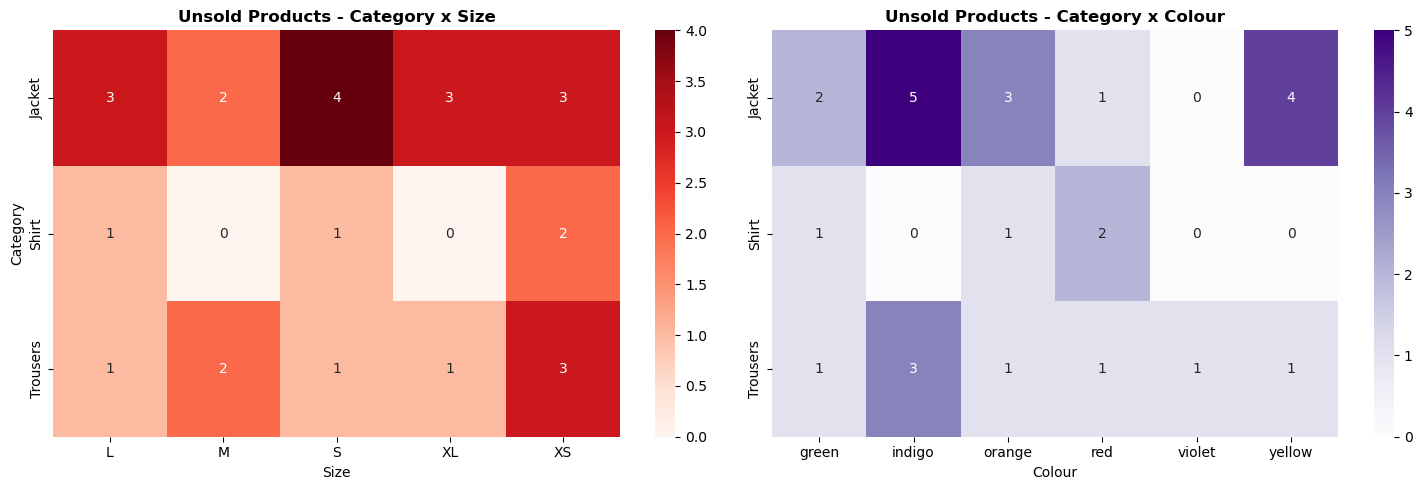

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# pivot tables
size_pivot = unsold_df.pivot_table(index='product_type', columns='size', values='product_ID', aggfunc='count', fill_value=0)
colour_pivot = unsold_df.pivot_table(index='product_type', columns='colour', values='product_ID', aggfunc='count', fill_value=0)

# figure layout
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.heatmap(size_pivot, annot=True, fmt='g', cmap='Reds', ax=axes[0])
axes[0].set_title("Unsold Products - Category x Size", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Category")

sns.heatmap(colour_pivot, annot=True, fmt='g', cmap='Purples', ax=axes[1])
axes[1].set_title("Unsold Products - Category x Colour", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Colour")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


In [100]:
size_pivot = unsold_df.pivot_table(index='product_type', columns='size', values='product_ID', aggfunc='count',fill_value=0)

colour_pivot = unsold_df.pivot_table(index='product_type',columns='colour',values='product_ID',aggfunc='count',fill_value=0)
     
# convert to percentages (row-wise total)
size_percent = (size_pivot.div(size_pivot.sum(axis=1), axis=0) * 100).round(2)
colour_percent = (colour_pivot.div(colour_pivot.sum(axis=1), axis=0) * 100).round(2)

print("Size % Table:")
print(size_percent)

print("\nColour % Table:")
print(colour_percent)



Size % Table:
size             L      M      S    XL    XS
product_type                                
Jacket        20.0  13.33  26.67  20.0  20.0
Shirt         25.0   0.00  25.00   0.0  50.0
Trousers      12.5  25.00  12.50  12.5  37.5

Colour % Table:
colour        green  indigo  orange    red  violet  yellow
product_type                                              
Jacket        13.33   33.33    20.0   6.67     0.0   26.67
Shirt         25.00    0.00    25.0  50.00     0.0    0.00
Trousers      12.50   37.50    12.5  12.50    12.5   12.50


1. Size-Based Insights (Category × Size)

- XS and S sizes show the highest concentration of unsold SKUs, especially in Jackets and Trousers.
→ Demand skews toward core sizes (M–L), while fringe sizes are harder to convert.

- Shirts have 50% XS unsold, indicating that extra-small options are overrepresented relative to customer demand.

- Jackets show distribution across all sizes, but S (26.67%) and XS (20%) remain the weakest performers.

 2. Colour-Based Insights (Category × Colour)

- Indigo and Yellow show the highest unsold concentration in Jackets
- → These shades may have lower aesthetic appeal in outerwear.

- Shirts exhibit issues with Red and Orange variants (75% of unsold shirts).

- Trousers show a scattered pattern, but Indigo again stands out as a problematic colour (37.5%).

In [41]:
active_mean_price = df['price_per_unit'].mean()
unsold_mean_price = unsold_df['price'].mean()

active_mean_price, unsold_mean_price

(103.5016, 104.5925925925926)

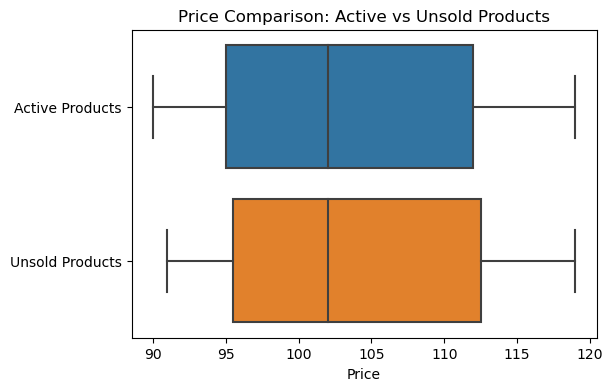

In [42]:
# Price Comparison: Check whether pricing affects unsold items
plt.figure(figsize=(6,4))
sns.boxplot(data=[df['price_per_unit'], unsold_df['price']], orient='h')
plt.yticks([0,1], ['Active Products', 'Unsold Products'])
plt.title("Price Comparison: Active vs Unsold Products")
plt.xlabel("Price")
plt.show()


Insights:

- No evidence of pricing barrier

- Unsold products’ avg price ≈ Active product price
  - Pricing strategy is consistent and not the primary issue

# Product Segment Distribution (Including Unsold)

In [89]:
total_products = products['product_ID'].nunique()
segment_distribution = metric_df['segment'].value_counts()

# Append unsold products as an additional segment
segment_data = segment_distribution.to_dict()
segment_data['Unsold Products'] = unsold_count

segment_df = pd.DataFrame(
    list(segment_data.items()), 
    columns=['Segment', 'Product Count']
)
segment_df['Percent'] = (
    segment_df['Product Count'] / total_products * 100
).round(2).astype(str) + "%"

print(segment_df)
print(f"\nTotal Products: {total_products}")
print(f"Sold Products: {total_products - unsold_count}")
print(f"Unsold Products: {unsold_count}")

                   Segment  Product Count Percent
0          High Performers            375  29.76%
1          Underperformers            311  24.68%
2  Premium / Niche Segment            275  21.83%
3          Volume Products            272  21.59%
4          Unsold Products             27   2.14%

Total Products: 1260
Sold Products: 1233
Unsold Products: 27


In [91]:
# Segment Distribution Pie Chart

import plotly.express as px 

fig = px.pie(
    segment_df,
    values='Product Count',
    names='Segment',
    title=f'Product Segmentation Including Unsold Inventory (Total: {total_products})',
    hover_data=['Percent'],
    labels={'Percent': 'Share (%)'},
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.update_layout(width=900, height=700)
fig.show()

Insights:

- Despite a healthy sell-through rate, only 27 SKUs (stock keeping unit) (≈2.1%) recorded zero sales — indicating that the overall assortment strategy is well aligned with demand.